In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.9 MB/s eta 0:00:00


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

In [3]:
RANDOM_STATE  = 42
TEST_SIZE     = 0.2
N_QUBITS      = 6
CLASSES       = ["malignant", "benign"]

np.random.seed(RANDOM_STATE)

In [4]:
def load_dataset():
    data = load_breast_cancer()
    X, y = data.data, data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    print(f"Dataset : Wisconsin Breast Cancer")
    print(f"Total   : {len(X)} échantillons, {X.shape[1]} features")
    print(f"Train   : {len(X_train)} | Test : {len(X_test)}")
    print(f"Classes : 0=malin ({(y==0).sum()}), 1=bénin ({(y==1).sum()})")
    return X_train, X_test, y_train, y_test

In [5]:

def run_classic_svm_full(X_train, X_test, y_train, y_test):
    param_grid = [
        {"kernel": ["rbf"],
         "C":     [0.1, 1, 10, 100],
         "gamma": ["scale", 0.001, 0.01, 0.1, 1]},
        {"kernel": ["linear"],
         "C":     [0.1, 1, 10, 100]},
    ]

    t0 = time.time()
    grid = GridSearchCV(
        SVC(probability=True),
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="accuracy",
        n_jobs=-1,
        verbose=1,
    )
    grid.fit(X_train, y_train)
    search_time = time.time() - t0
    t0 = time.time()
    final_model = SVC(probability=True, **grid.best_params_).fit(X_train, y_train)
    single_train_time = time.time() - t0

    y_pred  = final_model.predict(X_test)
    y_proba = final_model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    return {
        "model": final_model,
        "best_params": grid.best_params_,
        "accuracy": acc,
        "auc": auc,
        "search_time_sec": search_time,
        "single_train_time_sec": single_train_time,
        "y_pred": y_pred,
    }

In [6]:
def run_classic_svm_with_pca(X_train, X_test, y_train, y_test, n_components):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    explained   = pca.explained_variance_ratio_.sum()

    param_grid = [
        {"kernel": ["rbf"],
         "C":     [0.1, 1, 10, 100],
         "gamma": ["scale", 0.001, 0.01, 0.1, 1]},
        {"kernel": ["linear"],
         "C":     [0.1, 1, 10, 100]},
    ]
    t0 = time.time()
    grid = GridSearchCV(
        SVC(probability=True),
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="accuracy",
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train_pca, y_train)
    search_time = time.time() - t0

    final_model = SVC(probability=True, **grid.best_params_).fit(X_train_pca, y_train)
    y_pred  = final_model.predict(X_test_pca)
    y_proba = final_model.predict_proba(X_test_pca)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)

    return {
        "accuracy": acc,
        "auc": auc,
        "best_params": grid.best_params_,
        "explained_variance": explained,
        "search_time_sec": search_time,
        "y_pred": y_pred,
    }

In [7]:
def zz_feature_map(x, n_qubits, reps, entanglement='linear'):
    if entanglement == 'linear':
        pairs = [(i, i + 1) for i in range(n_qubits - 1)]
    elif entanglement == 'circular':
        pairs = [(i, (i + 1) % n_qubits) for i in range(n_qubits)]
    elif entanglement == 'full':
        pairs = [(i, j) for i in range(n_qubits)
                         for j in range(i + 1, n_qubits)]
    else:
        raise ValueError(f"entanglement inconnu : {entanglement}. "
                         f"Choisir parmi 'linear', 'circular', 'full'.")

    for _ in range(reps):
        for i in range(n_qubits):
            qml.RZ(x[i], wires=i)

        for i, j in pairs:
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * x[i] * x[j], wires=j)
            qml.CNOT(wires=[i, j])

In [8]:
def compute_quantum_kernel(X_a, X_b=None, n_qubits=None,
                            reps=1, entanglement='linear'):
    if n_qubits is None:
        n_qubits = X_a.shape[1]

    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        zz_feature_map(x1, n_qubits, reps, entanglement)
        qml.adjoint(zz_feature_map)(x2, n_qubits, reps, entanglement)
        return qml.probs(wires=range(n_qubits))

    def fidelity(x1, x2):
        probs = kernel_circuit(x1, x2)
        return float(probs[0])

    symmetric = (X_b is None)
    if symmetric:
        X_b = X_a

    n_a, n_b = len(X_a), len(X_b)
    K = np.zeros((n_a, n_b))
    if symmetric:
        for i in range(n_a):
            for j in range(i, n_b):
                val = fidelity(X_a[i], X_b[j])
                K[i, j] = val
                K[j, i] = val
    else:
        for i in range(n_a):
            for j in range(n_b):
                K[i, j] = fidelity(X_a[i], X_b[j])

    return K

In [9]:
def run_qsvm(X_train, X_test, y_train, y_test,
             n_components, reps=(1, 2), C_values=(1, 10, 100),
             entanglements=('linear', 'circular', 'full'),
             verbose=True):

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    explained   = pca.explained_variance_ratio_.sum()

    
    qscaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
    X_train_q = qscaler.fit_transform(X_train_pca)
    X_test_q  = qscaler.transform(X_test_pca)
    if verbose:
        print(f"\n  >> n_qubits = {n_components} | variance expliquée = {explained*100:.1f}%")
        print(f"  {'Entangl.':<10}{'Reps':<6}{'C':<8}{'Accuracy':<12}{'AUC':<10}{'Kernel(s)':<12}{'Train(s)':<10}")
        print("  " + "-" * 68)

    best_acc, best_result, total_search_time = -1, None, 0.0
    all_results = [] 
    
    for entanglement in entanglements:
        for r in reps:
            # Calcul du kernel — une seule fois par (entanglement, reps)
            t0 = time.time()
            K_train = compute_quantum_kernel(
                X_train_q, n_qubits=n_components,
                reps=r, entanglement=entanglement)
            K_test  = compute_quantum_kernel(
                X_test_q, X_train_q, n_qubits=n_components,
                reps=r, entanglement=entanglement)
            kernel_time = time.time() - t0

            # Recherche sur C (kernel réutilisé pour chaque C)
            for C in C_values:
                t0 = time.time()
                qsvc = SVC(kernel="precomputed", C=C, probability=True)
                qsvc.fit(K_train, y_train)
                train_time = time.time() - t0

                y_pred  = qsvc.predict(K_test)
                y_proba = qsvc.predict_proba(K_test)[:, 1]
                acc     = accuracy_score(y_test, y_pred)
                auc     = roc_auc_score(y_test, y_proba)
                total_search_time += kernel_time + train_time

                iteration_result = {
                    "n_qubits": n_components,
                    "entanglement": entanglement,
                    "reps": r,
                    "C": C,
                    "accuracy": acc,
                    "auc": auc,
                    "kernel_time_sec": kernel_time,
                    "train_time_sec": train_time,
                    "explained_variance": explained,
                }
                all_results.append(iteration_result)

                # ── AFFICHAGE DE CHAQUE ITERATION ──
                if verbose:
                    print(f"  {entanglement:<10}{r:<6}{C:<8}{acc:<12.4f}{auc:<10.4f}"
                          f"{kernel_time:<12.2f}{train_time:<10.4f}")

                if acc > best_acc:
                    best_acc = acc
                    best_result = {
                        "accuracy": acc,
                        "auc": auc,
                        "reps": r,
                        "C": C,
                        "entanglement": entanglement,
                        "explained_variance": explained,
                        "kernel_time_sec": kernel_time,
                        "single_train_time_sec": train_time,
                        "y_pred": y_pred,
                    }

    best_result["search_time_sec"] = total_search_time
    best_result["all_results"] = all_results
    if verbose:
        print("  " + "-" * 68)
        print(f"  >> MEILLEUR pour n_qubits={n_components} : "
              f"entanglement={best_result['entanglement']}, reps={best_result['reps']}, "
              f"C={best_result['C']} -> accuracy={best_result['accuracy']:.4f}, "
              f"AUC={best_result['auc']:.4f}")

    return best_result
    

Dataset : Wisconsin Breast Cancer
Total   : 569 échantillons, 30 features
Train   : 455 | Test : 114
Classes : 0=malin (212), 1=bénin (357)

1) SVM CLASSIQUE COMPLET (30 features, grid search complet)
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs hyperparamètres : {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy / AUC            : 0.9825 / 0.9977
Temps de recherche        : 4.3 s

2) SVM CLASSIQUE + PCA (6 composantes) — contrôle
Variance expliquée        : 89.1%
Meilleurs hyperparamètres : {'C': 10, 'kernel': 'linear'}
Accuracy / AUC            : 0.9386 / 0.9934
Temps de recherche        : 1.6 s

3) QSVM — TOUTES LES ITERATIONS (6 qubits, tous parametres)

  >> n_qubits = 6 | variance expliquée = 89.1%
  Entangl.  Reps  C       Accuracy    AUC       Kernel(s)   Train(s)  
  --------------------------------------------------------------------
  linear    1     1       0.6316      0.5324    1230.47     0.0092    
  linear    1     10      0.6316      0.5799  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Graphique sauvegardé : entanglement_comparison.png

4) COURBE Accuracy par nombre de répétitions (reps) — n_qubits=6
Graphique sauvegardé : accuracy_vs_reps_6qubits.png


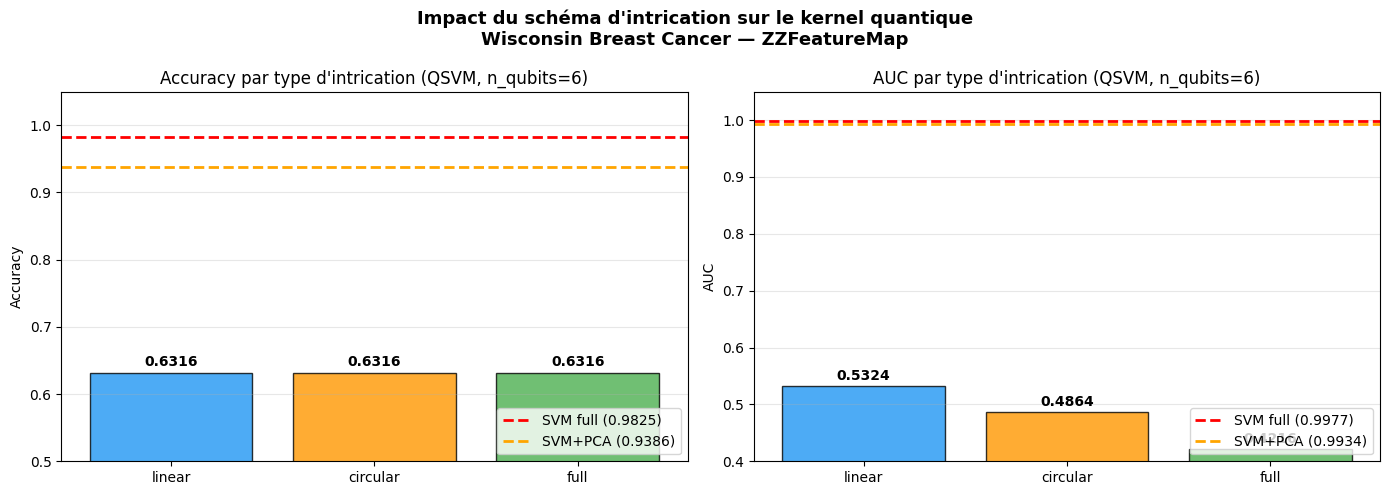

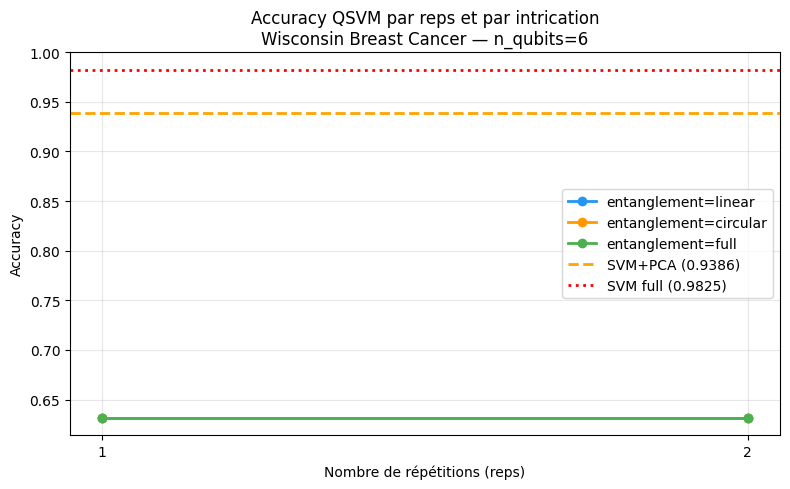

In [10]:
if __name__ == "__main__":

    X_train, X_test, y_train, y_test = load_dataset()

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print("\n" + "=" * 70)
    print("1) SVM CLASSIQUE COMPLET (30 features, grid search complet)")
    print("=" * 70)
    res_svm_full = run_classic_svm_full(X_train_sc, X_test_sc, y_train, y_test)
    print(f"Meilleurs hyperparamètres : {res_svm_full['best_params']}")
    print(f"Accuracy / AUC            : {res_svm_full['accuracy']:.4f} / {res_svm_full['auc']:.4f}")
    print(f"Temps de recherche        : {res_svm_full['search_time_sec']:.1f} s")

    
    print("\n" + "=" * 70)
    print(f"2) SVM CLASSIQUE + PCA ({N_QUBITS} composantes) — contrôle")
    print("=" * 70)
    res_svm_pca = run_classic_svm_with_pca(
        X_train_sc, X_test_sc, y_train, y_test, n_components=N_QUBITS)
    print(f"Variance expliquée        : {res_svm_pca['explained_variance']*100:.1f}%")
    print(f"Meilleurs hyperparamètres : {res_svm_pca['best_params']}")
    print(f"Accuracy / AUC            : {res_svm_pca['accuracy']:.4f} / {res_svm_pca['auc']:.4f}")
    print(f"Temps de recherche        : {res_svm_pca['search_time_sec']:.1f} s")

    print("\n" + "=" * 70)
    print("3) QSVM — TOUTES LES ITERATIONS (6 qubits, tous parametres)")
    print("=" * 70)

    qubit_range = [N_QUBITS] 
    all_qsvm_runs = {}       
    all_iterations_global = []  

    for n in qubit_range:
        res_n = run_qsvm(
            X_train_sc, X_test_sc, y_train, y_test,
            n_components=n,
            reps=(1, 2),
            C_values=(1, 10, 100),
            entanglements=('linear', 'circular', 'full'),
            verbose=True
        )
        all_qsvm_runs[n] = res_n
        all_iterations_global.extend(res_n["all_results"])

    res_qsvm = max(all_qsvm_runs.values(), key=lambda r: r["accuracy"])

    
    print("\n" + "=" * 90)
    print("TABLEAU COMPLET — TOUTES LES ITERATIONS (tous n_qubits, tous entanglements, tous reps, tous C)")
    print("=" * 90)
    print(f"{'n_qubits':<10}{'Entangl.':<12}{'Reps':<6}{'C':<8}{'Accuracy':<12}{'AUC':<10}{'Kernel(s)':<12}{'Train(s)':<10}")
    print("-" * 90)
    for r in sorted(all_iterations_global,
                     key=lambda x: (x['n_qubits'], x['entanglement'], x['reps'], x['C'])):
        print(f"{r['n_qubits']:<10}{r['entanglement']:<12}{r['reps']:<6}{r['C']:<8}"
              f"{r['accuracy']:<12.4f}{r['auc']:<10.4f}{r['kernel_time_sec']:<12.2f}{r['train_time_sec']:<10.4f}")

    print("\n" + "=" * 70)
    print("MEILLEURE CONFIGURATION PAR NOMBRE DE QUBITS")
    print("=" * 70)
    print(f"{'n_qubits':<10}{'Entangl.':<12}{'Reps':<6}{'C':<8}{'Accuracy':<12}{'AUC':<10}")
    print("-" * 60)
    for n in qubit_range:
        best = all_qsvm_runs[n]
        print(f"{n:<10}{best['entanglement']:<12}{best['reps']:<6}{best['C']:<8}"
              f"{best['accuracy']:<12.4f}{best['auc']:<10.4f}")

    print("\n" + "=" * 70)
    print("RÉCAPITULATIF GLOBAL")
    print("=" * 70)
    print(f"{'Méthode':<35}{'Accuracy':<12}{'AUC':<10}{'Temps (s)':<12}")
    print("-" * 70)
    print(f"{'SVM classique (full)':<35}"
          f"{res_svm_full['accuracy']:<12.4f}"
          f"{res_svm_full['auc']:<10.4f}"
          f"{res_svm_full['search_time_sec']:<12.1f}")
    print(f"{'SVM classique + PCA':<35}"
          f"{res_svm_pca['accuracy']:<12.4f}"
          f"{res_svm_pca['auc']:<10.4f}"
          f"{res_svm_pca['search_time_sec']:<12.1f}")
    print(f"{'QSVM (meilleure config globale)':<35}"
          f"{res_qsvm['accuracy']:<12.4f}"
          f"{res_qsvm['auc']:<10.4f}"
          f"{res_qsvm['search_time_sec']:<12.1f}")


    print("\n" + "=" * 70)
    print("DÉCOMPOSITION DE L'ÉCART DE PERFORMANCE")
    print("=" * 70)
    ecart_total  = res_svm_full['accuracy'] - res_qsvm['accuracy']
    ecart_pca    = res_svm_full['accuracy'] - res_svm_pca['accuracy']
    ecart_kernel = res_svm_pca['accuracy']  - res_qsvm['accuracy']
    print(f"Écart total  (SVM full → QSVM)        : {ecart_total*100:.1f} points")
    if ecart_total != 0:
        print(f"Contribution PCA (SVM full → SVM+PCA) : {ecart_pca*100:.1f} points "
              f"({ecart_pca/ecart_total*100:.0f}% de l'écart total)")
        print(f"Contribution kernel quantique          : {ecart_kernel*100:.1f} points "
              f"({ecart_kernel/ecart_total*100:.0f}% de l'écart total)")

    
    print("\nMatrice de confusion — QSVM (meilleure config globale) :")
    print(confusion_matrix(y_test, res_qsvm["y_pred"]))
    print("\nClassification report — QSVM :")
    print(classification_report(y_test, res_qsvm["y_pred"], target_names=CLASSES))

    
    ref_results = all_qsvm_runs[N_QUBITS]["all_results"] if N_QUBITS in all_qsvm_runs else all_iterations_global

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    entanglement_types = ['linear', 'circular', 'full']
    colors = ['#2196F3', '#FF9800', '#4CAF50']

    acc_by_entanglement = {}
    auc_by_entanglement = {}
    for ent in entanglement_types:
        ent_results = [r for r in ref_results if r['entanglement'] == ent]
        best = max(ent_results, key=lambda x: x['accuracy'])
        acc_by_entanglement[ent] = best['accuracy']
        auc_by_entanglement[ent] = best['auc']

    bars = axes[0].bar(entanglement_types,
                       [acc_by_entanglement[e] for e in entanglement_types],
                       color=colors, alpha=0.8, edgecolor='black')
    axes[0].axhline(res_svm_full['accuracy'], color='red', linestyle='--',
                    label=f"SVM full ({res_svm_full['accuracy']:.4f})", linewidth=2)
    axes[0].axhline(res_svm_pca['accuracy'], color='orange', linestyle='--',
                    label=f"SVM+PCA ({res_svm_pca['accuracy']:.4f})", linewidth=2)
    for bar, ent in zip(bars, entanglement_types):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f"{acc_by_entanglement[ent]:.4f}",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].set_title(f"Accuracy par type d'intrication (QSVM, n_qubits={N_QUBITS})", fontsize=12)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0.5, 1.05)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3, axis='y')

    bars2 = axes[1].bar(entanglement_types,
                        [auc_by_entanglement[e] for e in entanglement_types],
                        color=colors, alpha=0.8, edgecolor='black')
    axes[1].axhline(res_svm_full['auc'], color='red', linestyle='--',
                    label=f"SVM full ({res_svm_full['auc']:.4f})", linewidth=2)
    axes[1].axhline(res_svm_pca['auc'], color='orange', linestyle='--',
                    label=f"SVM+PCA ({res_svm_pca['auc']:.4f})", linewidth=2)
    for bar, ent in zip(bars2, entanglement_types):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f"{auc_by_entanglement[ent]:.4f}",
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].set_title(f"AUC par type d'intrication (QSVM, n_qubits={N_QUBITS})", fontsize=12)
    axes[1].set_ylabel("AUC")
    axes[1].set_ylim(0.4, 1.05)
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle("Impact du schéma d'intrication sur le kernel quantique\n"
                 "Wisconsin Breast Cancer — ZZFeatureMap",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("entanglement_comparison.png", dpi=150, bbox_inches='tight')
    print("\nGraphique sauvegardé : entanglement_comparison.png")


    print("\n" + "=" * 70)
    print(f"4) COURBE Accuracy par nombre de répétitions (reps) — n_qubits={N_QUBITS}")
    print("=" * 70)

    plt.figure(figsize=(8, 5))
    reps_values = [1, 2]
    for ent, color in zip(entanglement_types, colors):
        acc_per_rep = []
        for r in reps_values:
            match = [x for x in ref_results if x['entanglement'] == ent and x['reps'] == r]
            best_for_rep = max(match, key=lambda x: x['accuracy'])
            acc_per_rep.append(best_for_rep['accuracy'])
        plt.plot(reps_values, acc_per_rep, marker="o", linewidth=2,
                 label=f"entanglement={ent}", color=color)

    plt.axhline(res_svm_pca["accuracy"], color="orange", linestyle="--",
                linewidth=2, label=f"SVM+PCA ({res_svm_pca['accuracy']:.4f})")
    plt.axhline(res_svm_full["accuracy"], color="red", linestyle=":",
                linewidth=2, label=f"SVM full ({res_svm_full['accuracy']:.4f})")
    plt.xticks(reps_values)
    plt.xlabel("Nombre de répétitions (reps)")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy QSVM par reps et par intrication\nWisconsin Breast Cancer — n_qubits={N_QUBITS}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("accuracy_vs_reps_6qubits.png", dpi=150)
    print("Graphique sauvegardé : accuracy_vs_reps_6qubits.png")